# Imports


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
color_plt=sns.color_palette()
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Reference Plot

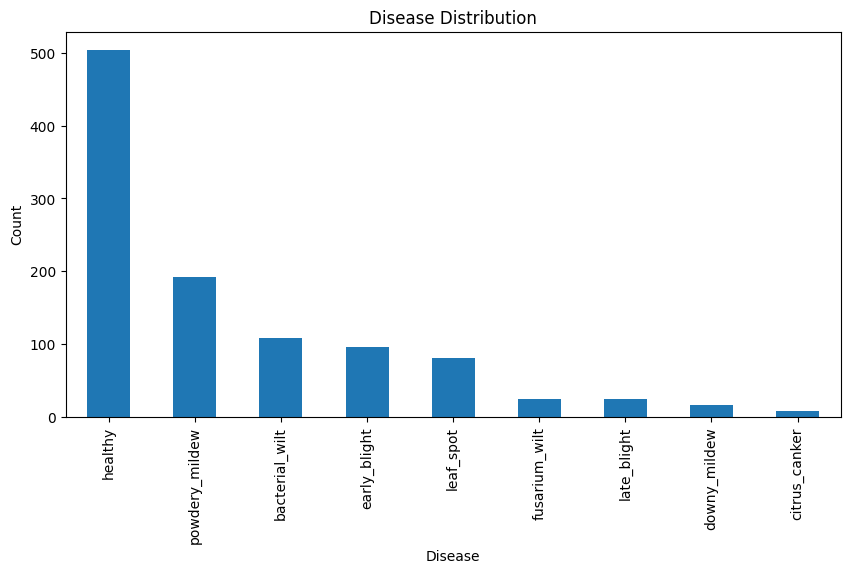

In [3]:
data=pd.read_csv("data.csv")
data["disease"].value_counts().plot(kind="bar", figsize=(10,5))

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")

plt.show()

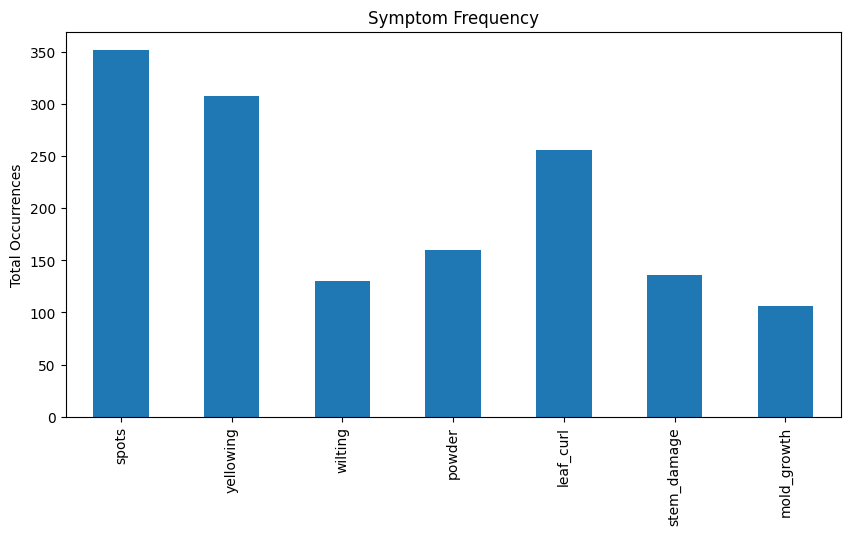

In [4]:
symptoms = [
    "spots",
    "yellowing",
    "wilting",
    "powder",
    "leaf_curl",
    "stem_damage",
    "mold_growth"
]

data[symptoms].sum().plot(kind="bar", figsize=(10,5))

plt.title("Symptom Frequency")
plt.ylabel("Total Occurrences")
plt.show()

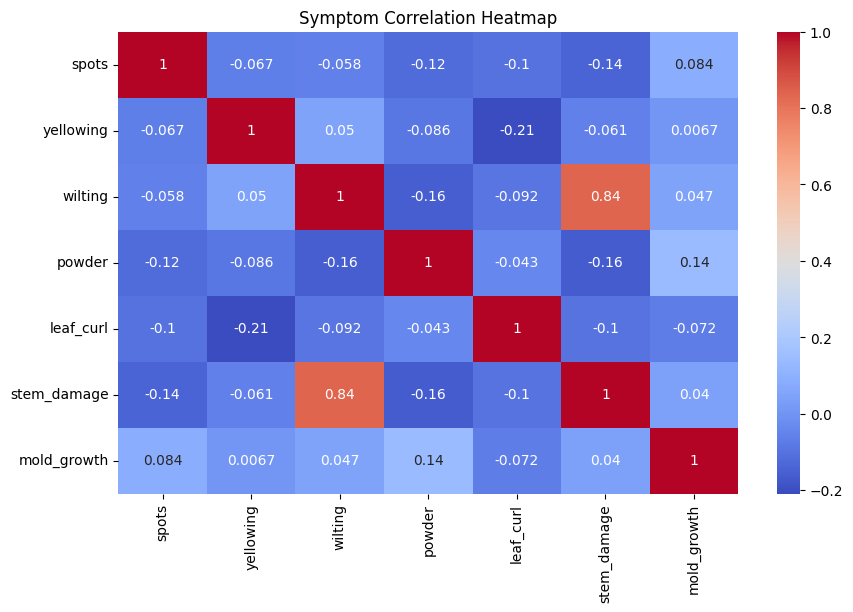

In [5]:
plt.figure(figsize=(10,6))

sns.heatmap(
    data[symptoms].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Symptom Correlation Heatmap")
plt.show()

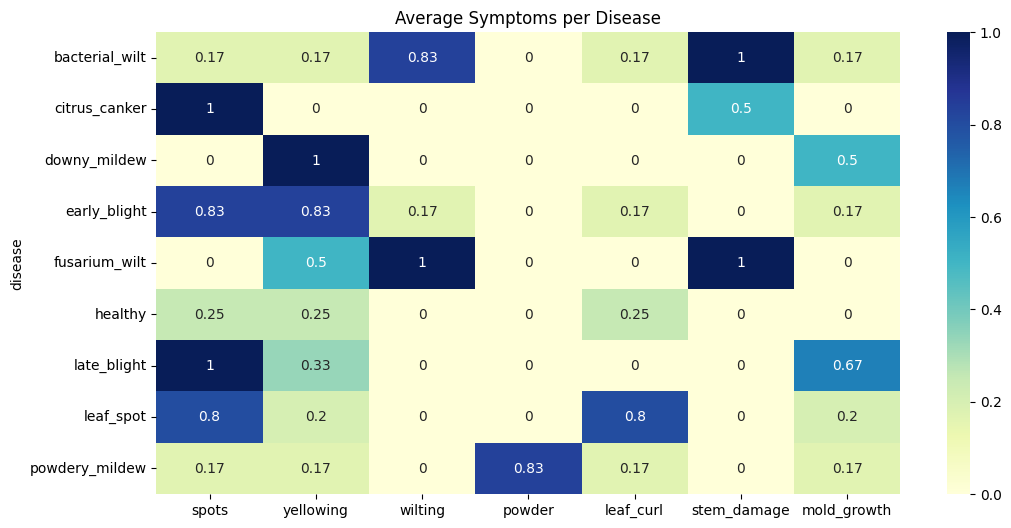

In [6]:


pivot = data.groupby("disease")[symptoms].mean()

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Average Symptoms per Disease")
plt.show()

# Train / Test Split


In [7]:
from sklearn.preprocessing import LabelEncoder

plant_encoder = LabelEncoder()
humidity_encoder = LabelEncoder()
temperature_encoder = LabelEncoder()
soil_encoder = LabelEncoder()
disease_encoder = LabelEncoder()

data["plant_type"] = plant_encoder.fit_transform(data["plant_type"])

data["humidity"] = humidity_encoder.fit_transform(data["humidity"])

data["temperature"] = temperature_encoder.fit_transform(data["temperature"])

data["soil_moisture"] = soil_encoder.fit_transform(data["soil_moisture"])

data["disease"] = disease_encoder.fit_transform(data["disease"])

In [8]:

x = data.drop("disease", axis=1)
y = data["disease"]

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


# Graphs of train/test split


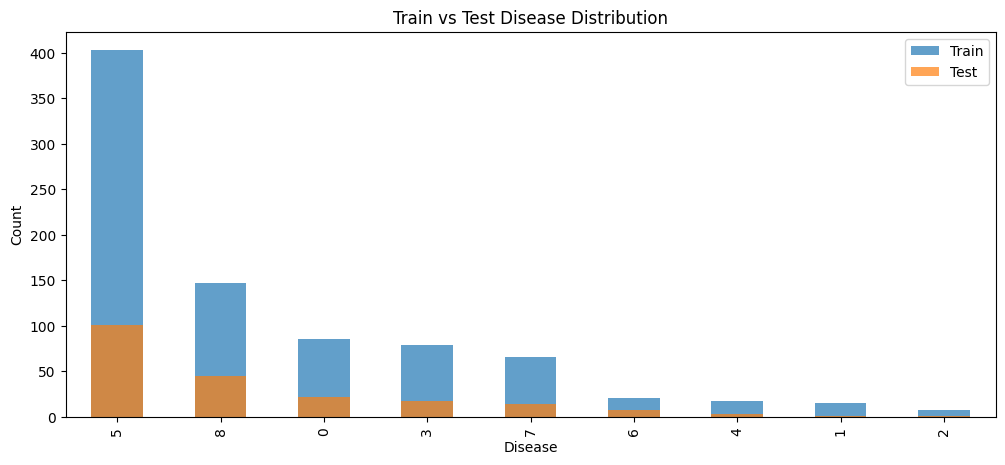

In [9]:
train_counts = y_train.value_counts()
test_counts = y_test.value_counts()

fig, ax = plt.subplots(figsize=(12,5))

train_counts.plot(kind="bar", ax=ax, alpha=0.7, label="Train")
test_counts.plot(kind="bar", ax=ax, alpha=0.7, label="Test",color=color_plt[1])

plt.title("Train vs Test Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.legend()

plt.show()




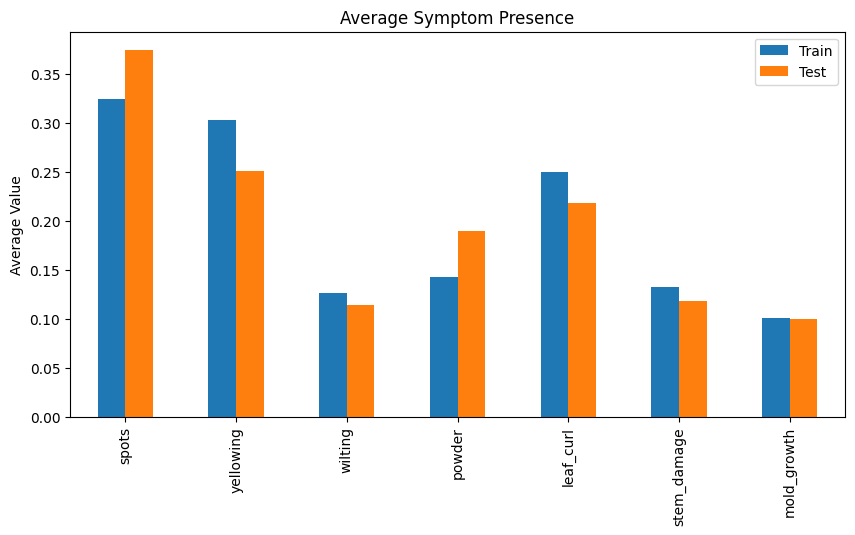

In [10]:
symptoms = [
    "spots",
    "yellowing",
    "wilting",
    "powder",
    "leaf_curl",
    "stem_damage",
    "mold_growth"
]

train_avg = X_train[symptoms].mean()
test_avg = X_test[symptoms].mean()

comparison = {
    "Train": train_avg,
    "Test": test_avg
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df.plot(kind="bar", figsize=(10,5))

plt.title("Average Symptom Presence")
plt.ylabel("Average Value")
plt.show()

# Training

In [11]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

# Testing

In [12]:
# actual_names = disease_encoder.inverse_transform(y_test)
# plant_names = plant_encoder.inverse_transform(
#     X_test["plant_type"]
# )
# c = 1

# for i in range(len(predicted_names)):
    
#     print("Test Case:", c)
#     print("plant name:",plant_names[i])
#     print("Input Features:")
#     print(X_test.iloc[i].to_dict())
    
#     print("Predicted Disease:", predicted_names[i])
    
#     print("Actual Disease:", actual_names[i])
    
#     print("-" * 50)
    
#     c += 1

In [13]:
# from sklearn.metrics import accuracy_score

# accuracy = accuracy_score(y_test, predictions)

# print("Accuracy:", accuracy)

# Custom Input

In [ ]:
custom_input = [[
    plant_encoder.transform(["tomato"])[0],
    1,   # spots
    0,   # yellowing
    0.0,  # wilting
    0.0,     # powder
    1,   # leaf_curl
    0.0,   # stem_damage
    0.0,   # mold_growth
    humidity_encoder.transform(["high"])[0],
    temperature_encoder.transform(["high"])[0],
    soil_encoder.transform(["wet"])[0]
]]

In [18]:
prediction=model.predict(custom_input)

C:\Users\Souro\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [19]:
disease_name = disease_encoder.inverse_transform(prediction)

print("Predicted Disease:", disease_name[0])

Predicted Disease: early_blight


In [ ]:
custom_input = [[
    plant_encoder.transform(["tomato"])[0],
    1,   # spots
    0,   # yellowing
    0.0,  # wilting
    0.0,     # powder
    1,   # leaf_curl
    0.0,   # stem_damage
    0.0,   # mold_growth
    humidity_encoder.transform(["high"])[0],
    temperature_encoder.transform(["high"])[0],
    soil_encoder.transform(["wet"])[0]
]]

prediction = model.predict(custom_input)
disease_name = disease_encoder.inverse_transform(prediction)[0]
print(f"Predicted Disease: {disease_name}")